# Student Dropout & Academic Success Prediction
**Model training notebook** for the Django web application.

**Goal:** predict whether a student will **Dropout**, remain **Enrolled**, or **Graduate** from enrollment and first/second-semester academic data.

**Dataset:** *Predict Students' Dropout and Academic Success* (UCI ML Repository, id 697, CC BY 4.0). 4,424 students, 36 features, 3 classes.

**Pipeline:** load → clean → EDA → compare models → tune best model → evaluate → export `model/student_model.pkl` + `model/model_meta.json` for Django.

> Place `students_dropout.csv` (the `data.csv` from UCI, semicolon-separated) next to this notebook. If it is missing, the notebook downloads it from UCI automatically.

## 1. Setup

In [1]:
import os, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
os.makedirs("figures", exist_ok=True)
os.makedirs("model", exist_ok=True)

## 2. Load the dataset

In [2]:
UCI_URL = "https://archive.ics.uci.edu/static/public/697/predict+students+dropout+and+academic+success.zip"

def load_data():
    # 1) local file (recommended)
    for p in ["students_dropout.csv", "data.csv", "data/students_dropout.csv", "data/data.csv"]:
        if os.path.exists(p):
            print("Loaded local file:", p)
            return pd.read_csv(p, sep=";")
    # 2) download the ZIP from UCI
    try:
        import io, zipfile, urllib.request
        with urllib.request.urlopen(UCI_URL) as r:
            z = zipfile.ZipFile(io.BytesIO(r.read()))
        name = [n for n in z.namelist() if n.endswith(".csv")][0]
        print("Downloaded from UCI:", name)
        return pd.read_csv(z.open(name), sep=";")
    except Exception as e:
        print("Direct download failed:", e)
    # 3) ucimlrepo package
    from ucimlrepo import fetch_ucirepo   # pip install ucimlrepo
    d = fetch_ucirepo(id=697)
    print("Loaded via ucimlrepo")
    return pd.concat([d.data.features, d.data.targets], axis=1)

df = load_data()
print(df.shape)
df.head()

Downloaded from UCI: data.csv
(4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Clean column names
The raw file has awkward names (spaces, apostrophes, a typo `Nacionality`, a hidden tab in one header). We convert everything to `snake_case`, which is also what the Django form will use.

In [3]:
def clean_col(c):
    return re.sub(r"[^a-z0-9]+", "_", c.strip().lower()).strip("_")

df.columns = [clean_col(c) for c in df.columns]
df = df.rename(columns={"nacionality": "nationality"})
print(list(df.columns))

['marital_status', 'application_mode', 'application_order', 'course', 'daytime_evening_attendance', 'previous_qualification', 'previous_qualification_grade', 'nationality', 'mother_s_qualification', 'father_s_qualification', 'mother_s_occupation', 'father_s_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment', 'international', 'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled', 'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations', 'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations', 'unemployment_rate', 'inflation_rate', 'gdp', 'target']


## 4. Exploratory data analysis

In [4]:
print("Shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
df.info()

Shape: (4424, 37)
Missing values: 0
Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   marital_status                                4424 non-null   int64  
 1   application_mode                              4424 non-null   int64  
 2   application_order                             4424 non-null   int64  
 3   course                                        4424 non-null   int64  
 4   daytime_evening_attendance                    4424 non-null   int64  
 5   previous_qualification                        4424 non-null   int64  
 6   previous_qualification_grade                  4424 non-null   float64
 7   nationality                                   4424 non-null   int64  
 8   mother_s_qualification                        4424 non-null   int64  
 9   father_s_

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
marital_status,4424.0,1.18,0.61,1.00,1.00,1.00,1.00,6.00
application_mode,4424.0,18.67,17.48,1.00,1.00,17.00,39.00,57.00
application_order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
course,4424.0,8856.64,2063.57,33.00,9085.00,9238.00,9556.00,9991.00
daytime_evening_attendance,4424.0,0.89,0.31,0.00,1.00,1.00,1.00,1.00
previous_qualification,4424.0,4.58,10.22,1.00,1.00,1.00,1.00,43.00
previous_qualification_grade,4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
nationality,4424.0,1.87,6.91,1.00,1.00,1.00,1.00,109.00
mother_s_qualification,4424.0,19.56,15.60,1.00,2.00,19.00,37.00,44.00
father_s_qualification,4424.0,22.28,15.34,1.00,3.00,19.00,37.00,44.00


### 4.1 Target distribution (class imbalance)

target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64 

target
Graduate    49.9 %
Dropout     32.1 %
Enrolled    17.9 %
Name: count, dtype: object


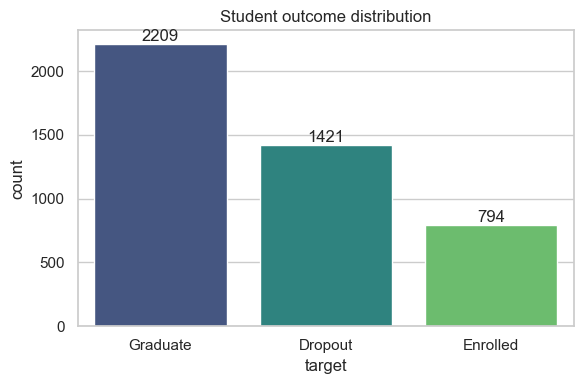

In [6]:
counts = df["target"].value_counts()
print(counts, "\n")
print((counts / len(df) * 100).round(1).astype(str) + " %")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="target", order=counts.index, palette="viridis", ax=ax)
ax.set_title("Student outcome distribution")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout(); plt.savefig("figures/01_target_distribution.png", dpi=150); plt.show()

### 4.2 Dropout vs. socio-economic factors

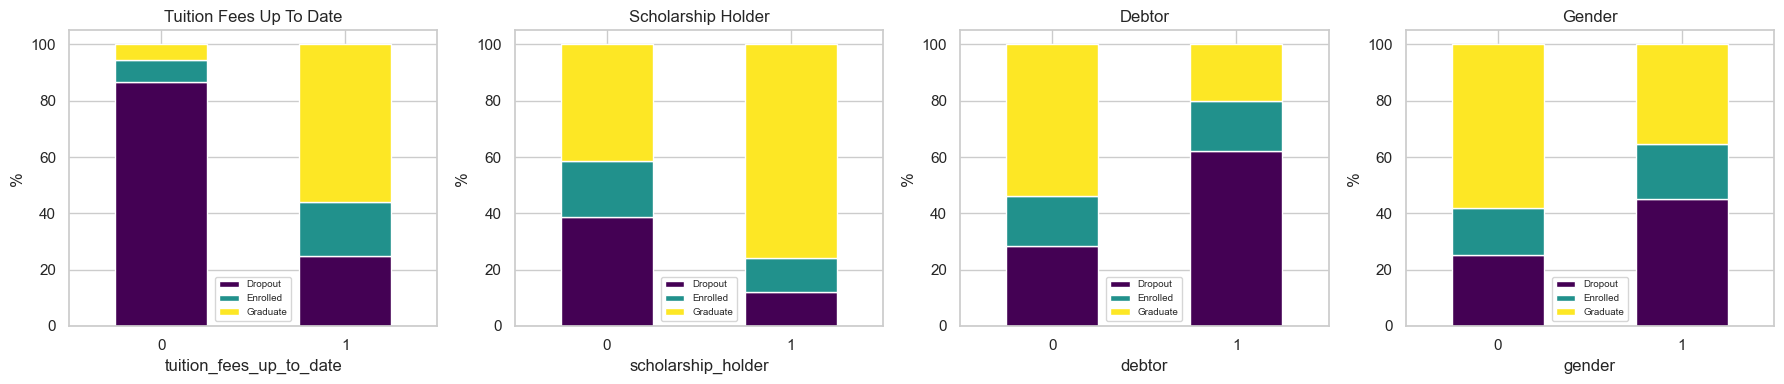

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ["tuition_fees_up_to_date", "scholarship_holder", "debtor", "gender"]):
    (pd.crosstab(df[col], df["target"], normalize="index") * 100).plot(
        kind="bar", stacked=True, ax=ax, colormap="viridis", rot=0)
    ax.set_title(col.replace("_", " ").title()); ax.set_ylabel("%"); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig("figures/02_socioeconomic_vs_target.png", dpi=150); plt.show()

### 4.3 Academic performance vs. outcome

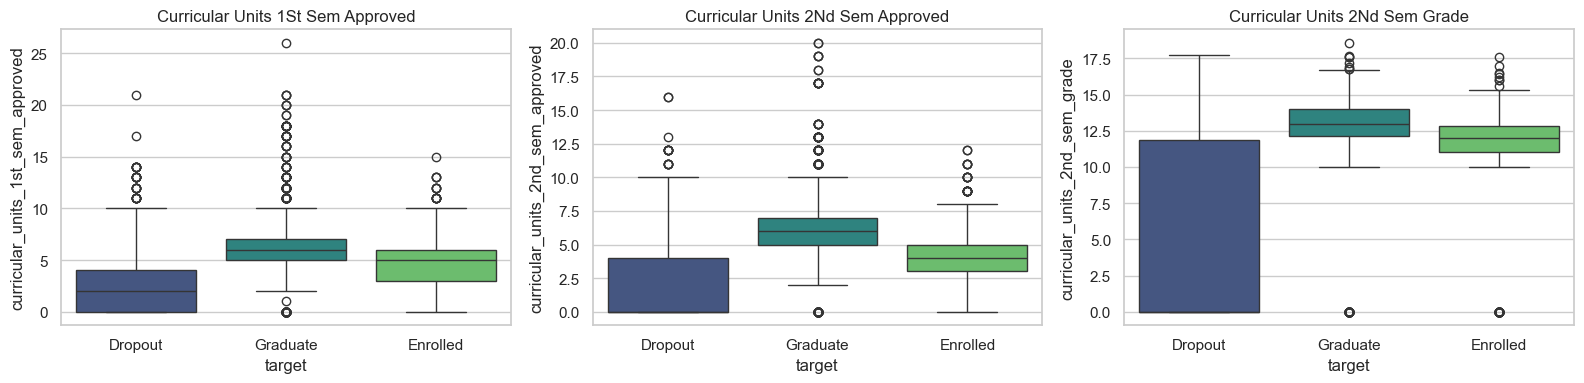

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["curricular_units_1st_sem_approved",
                          "curricular_units_2nd_sem_approved",
                          "curricular_units_2nd_sem_grade"]):
    sns.boxplot(data=df, x="target", y=col, palette="viridis", ax=ax)
    ax.set_title(col.replace("_", " ").title())
plt.tight_layout(); plt.savefig("figures/03_academic_vs_target.png", dpi=150); plt.show()

### 4.4 Age and admission grade

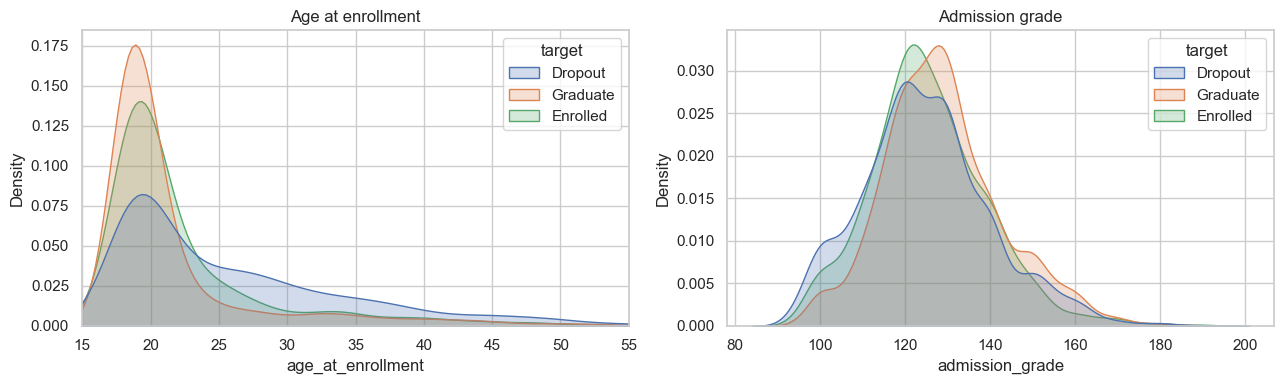

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.kdeplot(data=df, x="age_at_enrollment", hue="target", common_norm=False, fill=True, ax=axes[0])
axes[0].set_xlim(15, 55); axes[0].set_title("Age at enrollment")
sns.kdeplot(data=df, x="admission_grade", hue="target", common_norm=False, fill=True, ax=axes[1])
axes[1].set_title("Admission grade")
plt.tight_layout(); plt.savefig("figures/04_age_admission.png", dpi=150); plt.show()

### 4.5 Correlation with the outcome

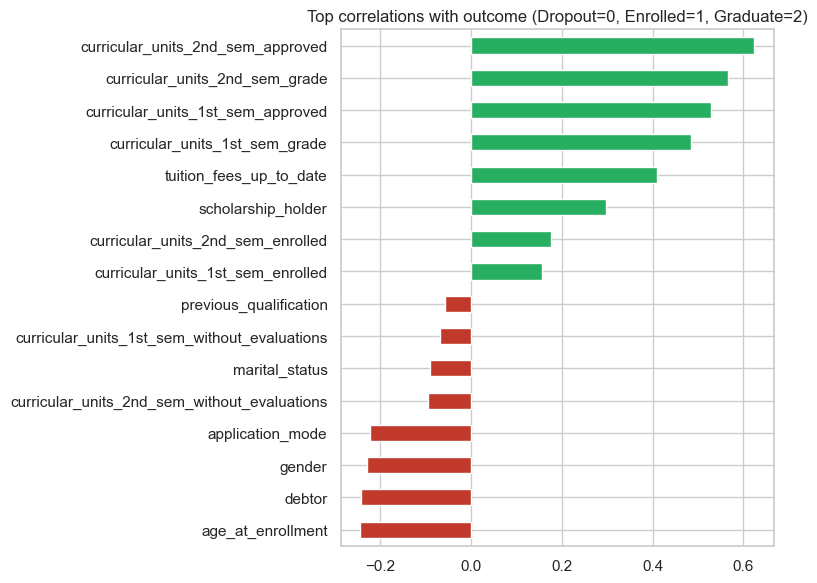

In [10]:
tmp = df.copy()
tmp["target_code"] = LabelEncoder().fit_transform(tmp["target"])   # Dropout=0, Enrolled=1, Graduate=2
corr = tmp.drop(columns="target").corr()["target_code"].drop("target_code").sort_values()
top = pd.concat([corr.head(8), corr.tail(8)])
fig, ax = plt.subplots(figsize=(8, 6))
top.plot(kind="barh", color=["#c0392b" if v < 0 else "#27ae60" for v in top], ax=ax)
ax.set_title("Top correlations with outcome (Dropout=0, Enrolled=1, Graduate=2)")
plt.tight_layout(); plt.savefig("figures/05_correlation_with_target.png", dpi=150); plt.show()

## 5. Prepare data
* Target is label-encoded: `Dropout=0`, `Enrolled=1`, `Graduate=2`.
* Columns such as `course`, `application_mode` and the parents' qualification/occupation are **category codes**, not quantities, so they are one-hot encoded for the full-feature models.
* We use a **stratified** 80/20 split because the classes are imbalanced.

In [11]:
le = LabelEncoder()
y = le.fit_transform(df["target"])
CLASS_NAMES = list(le.classes_)
print(dict(zip(CLASS_NAMES, range(len(CLASS_NAMES)))))

X = df.drop(columns="target")

CAT_COLS = [c for c in ["marital_status", "application_mode", "course", "daytime_evening_attendance",
                        "previous_qualification", "nationality", "mother_s_qualification",
                        "father_s_qualification", "mother_s_occupation", "father_s_occupation"]
            if c in X.columns]
NUM_COLS = [c for c in X.columns if c not in CAT_COLS]
print(len(CAT_COLS), "categorical-code columns,", len(NUM_COLS), "numeric columns")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

{'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
10 categorical-code columns, 26 numeric columns
Train: (3539, 36)  Test: (885, 36)


### 5.1 Two feature sets
1. **All features** (36 columns) – best possible accuracy, used as a benchmark.
2. **Deployment features** (14 columns) – a compact set a real user can type into a web form. Every input is numeric/binary, so no encoding is needed in Django.

We train both and check how much accuracy the compact set gives up.

In [12]:
DEPLOY_FEATURES = [
    "age_at_enrollment", "admission_grade", "previous_qualification_grade",
    "gender", "scholarship_holder", "debtor", "tuition_fees_up_to_date", "displaced",
    "curricular_units_1st_sem_enrolled", "curricular_units_1st_sem_approved", "curricular_units_1st_sem_grade",
    "curricular_units_2nd_sem_enrolled", "curricular_units_2nd_sem_approved", "curricular_units_2nd_sem_grade",
]
assert all(f in X.columns for f in DEPLOY_FEATURES)

def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced"),
        "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                                random_state=RANDOM_STATE, n_jobs=-1),
        "Gradient Boosting": HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        "SVM (RBF)": SVC(class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    }

def make_pipe(model, cat_cols, num_cols):
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=10), cat_cols),
        ("num", StandardScaler(), num_cols),
    ])
    return Pipeline([("prep", pre), ("clf", model)])

## 6. Compare models
5-fold stratified cross-validation on the training set, scored with **macro F1** (treats the small *Enrolled* class equally to the big ones), then a single evaluation on the untouched test set.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for set_name, cat_cols, num_cols in [
        ("All features (36)", CAT_COLS, NUM_COLS),
        ("Deployment features (14)", [], DEPLOY_FEATURES)]:
    cols = cat_cols + num_cols
    for name, model in get_models().items():
        pipe = make_pipe(model, cat_cols, num_cols)
        cv_f1 = cross_val_score(pipe, X_train[cols], y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
        pipe.fit(X_train[cols], y_train)
        pred = pipe.predict(X_test[cols])
        rows.append({"Feature set": set_name, "Model": name,
                     "CV macro-F1": cv_f1.mean(), "CV std": cv_f1.std(),
                     "Test accuracy": accuracy_score(y_test, pred),
                     "Test macro-F1": f1_score(y_test, pred, average="macro")})
        print(f"{set_name:26s} {name:20s} CV F1={cv_f1.mean():.3f}  Test acc={rows[-1]['Test accuracy']:.3f}")

results = pd.DataFrame(rows).round(4)
results

All features (36)          Logistic Regression  CV F1=0.709  Test acc=0.722


All features (36)          Random Forest        CV F1=0.681  Test acc=0.776


All features (36)          Gradient Boosting    CV F1=0.715  Test acc=0.748


All features (36)          SVM (RBF)            CV F1=0.711  Test acc=0.729
Deployment features (14)   Logistic Regression  CV F1=0.698  Test acc=0.745


Deployment features (14)   Random Forest        CV F1=0.681  Test acc=0.764


Deployment features (14)   Gradient Boosting    CV F1=0.684  Test acc=0.744


Deployment features (14)   SVM (RBF)            CV F1=0.695  Test acc=0.708


,Feature set,Model,CV macro-F1,CV std,Test accuracy,Test macro-F1
0,All features (36),Logistic Regression,0.7091,0.0150,0.7220,0.6852
1,All features (36),Random Forest,0.6811,0.0200,0.7763,0.6922
2,All features (36),Gradient Boosting,0.7148,0.0131,0.7480,0.6974
3,All features (36),SVM (RBF),0.7114,0.0128,0.7288,0.6896
4,Deployment features (14),Logistic Regression,0.6979,0.0117,0.7446,0.7093
5,Deployment features (14),Random Forest,0.6808,0.0162,0.7638,0.6822
6,Deployment features (14),Gradient Boosting,0.6839,0.0080,0.7435,0.6946
7,Deployment features (14),SVM (RBF),0.6953,0.0145,0.7085,0.6696


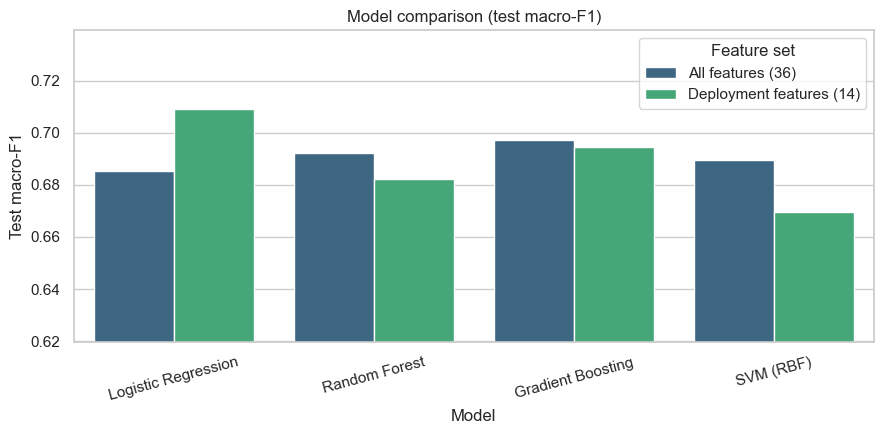

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=results, x="Model", y="Test macro-F1", hue="Feature set", palette="viridis", ax=ax)
ax.set_ylim(results["Test macro-F1"].min() - 0.05, results["Test macro-F1"].max() + 0.03)
ax.set_title("Model comparison (test macro-F1)")
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig("figures/06_model_comparison.png", dpi=150); plt.show()
results.to_csv("model/model_comparison.csv", index=False)

## 7. Tune the best deployment model
We pick the best algorithm on the **deployment feature set** by cross-validated macro-F1 (not test score, to avoid selecting on the test set) and tune it with randomized search.

In [15]:
dep = results[results["Feature set"].str.startswith("Deployment")].sort_values("CV macro-F1", ascending=False)
best_name = dep.iloc[0]["Model"]
print("Best deployment algorithm by CV:", best_name)

param_space = {
    "Logistic Regression": {"clf__C": [0.01, 0.1, 1, 10, 100]},
    "Random Forest": {"clf__n_estimators": [200, 300, 500], "clf__max_depth": [None, 8, 12, 16],
                      "clf__min_samples_leaf": [1, 2, 4], "clf__max_features": ["sqrt", "log2"]},
    "Gradient Boosting": {"clf__learning_rate": [0.03, 0.05, 0.1], "clf__max_iter": [150, 250, 400],
                          "clf__max_depth": [None, 4, 6], "clf__min_samples_leaf": [10, 20, 40],
                          "clf__l2_regularization": [0, 0.1, 1]},
    "SVM (RBF)": {"clf__C": [0.5, 1, 3, 10], "clf__gamma": ["scale", 0.01, 0.05]},
}
space = param_space[best_name]
n_combos = int(np.prod([len(v) for v in space.values()]))

search = RandomizedSearchCV(
    make_pipe(get_models()[best_name], [], DEPLOY_FEATURES),
    param_distributions=space, n_iter=min(20, n_combos), scoring="f1_macro",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
search.fit(X_train[DEPLOY_FEATURES], y_train)

print("Best CV macro-F1:", round(search.best_score_, 4))
print("Best params:", search.best_params_)
final_model = search.best_estimator_

Best deployment algorithm by CV: Logistic Regression


Best CV macro-F1: 0.6982
Best params: {'clf__C': 10}


## 8. Final evaluation on the test set

In [16]:
Xte = X_test[DEPLOY_FEATURES]
y_pred = final_model.predict(Xte)
y_proba = final_model.predict_proba(Xte)

acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")
f1w = f1_score(y_test, y_pred, average="weighted")
auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Accuracy: {acc:.4f} | Macro-F1: {f1m:.4f} | Weighted-F1: {f1w:.4f} | ROC-AUC (OvR): {auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Accuracy: 0.7446 | Macro-F1: 0.7093 | Weighted-F1: 0.7569 | ROC-AUC (OvR): 0.8708

              precision    recall  f1-score   support

     Dropout       0.86      0.69      0.76       284
    Enrolled       0.44      0.67      0.53       159
    Graduate       0.86      0.81      0.84       442

    accuracy                           0.74       885
   macro avg       0.72      0.72      0.71       885
weighted avg       0.78      0.74      0.76       885



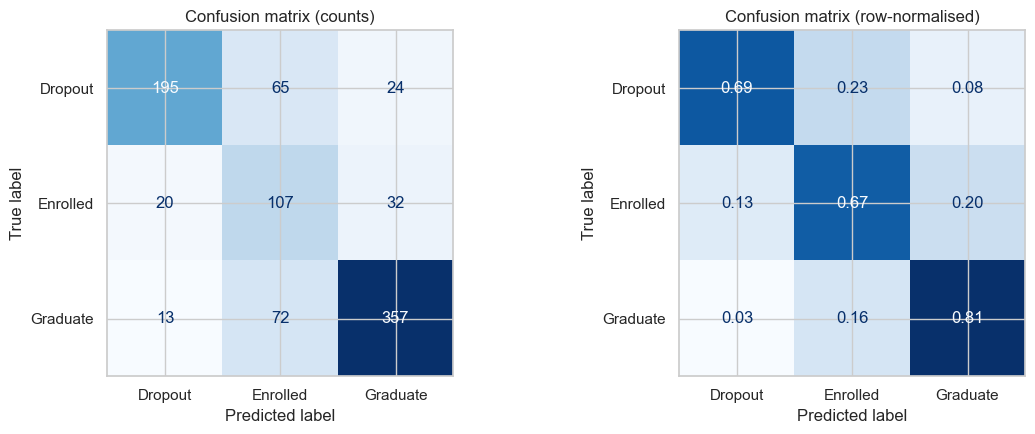

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=CLASS_NAMES,
                                        cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix (counts)")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=CLASS_NAMES,
                                        normalize="true", values_format=".2f",
                                        cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion matrix (row-normalised)")
plt.tight_layout(); plt.savefig("figures/07_confusion_matrix.png", dpi=150); plt.show()

### 8.1 Which features matter? (permutation importance on the test set)

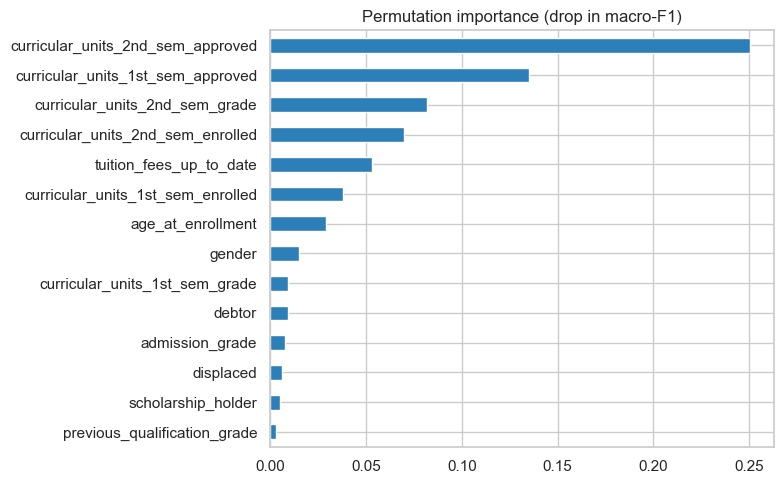

curricular_units_2nd_sem_approved    0.2505
curricular_units_1st_sem_approved    0.1351
curricular_units_2nd_sem_grade       0.0817
curricular_units_2nd_sem_enrolled    0.0700
tuition_fees_up_to_date              0.0532
curricular_units_1st_sem_enrolled    0.0380
age_at_enrollment                    0.0291
gender                               0.0147
curricular_units_1st_sem_grade       0.0092
debtor                               0.0090
admission_grade                      0.0076
displaced                            0.0060
scholarship_holder                   0.0050
previous_qualification_grade         0.0028
dtype: float64

In [18]:
pi = permutation_importance(final_model, Xte, y_test, n_repeats=10, scoring="f1_macro",
                            random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=DEPLOY_FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind="barh", color="#2c7fb8", ax=ax)
ax.set_title("Permutation importance (drop in macro-F1)")
plt.tight_layout(); plt.savefig("figures/08_feature_importance.png", dpi=150); plt.show()
imp.sort_values(ascending=False).round(4)

## 9. Export the model for Django
Saved to `model/`:
* `student_model.pkl` – full scikit-learn pipeline (scaler + classifier). Django just calls `predict_proba`.
* `model_meta.json` – feature order, labels, valid ranges (for form validation), class names and metrics.

In [19]:
LABELS = {
    "age_at_enrollment": ("Age at enrollment", "Age of the student when enrolling (years)"),
    "admission_grade": ("Admission grade", "Admission grade (0-200)"),
    "previous_qualification_grade": ("Previous qualification grade", "Grade of previous studies (0-200)"),
    "gender": ("Gender", "1 = Male, 0 = Female"),
    "scholarship_holder": ("Scholarship holder", "1 = Yes, 0 = No"),
    "debtor": ("Debtor", "1 = Student has unpaid debts, 0 = No"),
    "tuition_fees_up_to_date": ("Tuition fees up to date", "1 = Yes, 0 = No"),
    "displaced": ("Displaced", "1 = Lives away from home, 0 = No"),
    "curricular_units_1st_sem_enrolled": ("1st sem: units enrolled", "Course units enrolled in semester 1"),
    "curricular_units_1st_sem_approved": ("1st sem: units approved", "Course units passed in semester 1"),
    "curricular_units_1st_sem_grade": ("1st sem: average grade", "Average grade in semester 1 (0-20)"),
    "curricular_units_2nd_sem_enrolled": ("2nd sem: units enrolled", "Course units enrolled in semester 2"),
    "curricular_units_2nd_sem_approved": ("2nd sem: units approved", "Course units passed in semester 2"),
    "curricular_units_2nd_sem_grade": ("2nd sem: average grade", "Average grade in semester 2 (0-20)"),
}
BINARY = {"gender", "scholarship_holder", "debtor", "tuition_fees_up_to_date", "displaced"}

features_meta = []
for f in DEPLOY_FEATURES:
    s = df[f]
    features_meta.append({
        "name": f, "label": LABELS[f][0], "help": LABELS[f][1],
        "type": "binary" if f in BINARY else ("int" if pd.api.types.is_integer_dtype(s) else "float"),
        "min": float(s.min()), "max": float(s.max()),
        "mean": round(float(s.mean()), 2), "median": float(s.median()),
    })

meta = {
    "model_name": best_name,
    "best_params": {k.replace("clf__", ""): (v if isinstance(v, (int, float, str, type(None))) else str(v))
                    for k, v in search.best_params_.items()},
    "class_names": CLASS_NAMES,
    "features": features_meta,
    "metrics": {"accuracy": round(acc, 4), "macro_f1": round(f1m, 4),
                "weighted_f1": round(f1w, 4), "roc_auc_ovr": round(auc, 4)},
    "train_size": int(len(X_train)), "test_size": int(len(X_test)),
    "feature_importance": imp.sort_values(ascending=False).round(4).to_dict(),
    "class_distribution": df["target"].value_counts().to_dict(),
}

joblib.dump(final_model, "model/student_model.pkl")
with open("model/model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
df.to_csv("model/students_dropout_clean.csv", index=False)
print("Saved: model/student_model.pkl, model/model_meta.json, model/students_dropout_clean.csv")

Saved: model/student_model.pkl, model/model_meta.json, model/students_dropout_clean.csv


### 9.1 Sanity check: reload the model and predict one student like Django will

In [20]:
loaded = joblib.load("model/student_model.pkl")
sample = X_test[DEPLOY_FEATURES].iloc[[0]]
proba = loaded.predict_proba(sample)[0]
print(sample.T, "\n")
for c, p in zip(CLASS_NAMES, proba):
    print(f"{c:10s} {p*100:5.1f} %")
print("\nPredicted:", CLASS_NAMES[int(np.argmax(proba))], "| Actual:", CLASS_NAMES[y_test[0]])

                                         1853
age_at_enrollment                   20.000000
admission_grade                    160.000000
previous_qualification_grade       160.000000
gender                               1.000000
scholarship_holder                   0.000000
debtor                               0.000000
tuition_fees_up_to_date              1.000000
displaced                            1.000000
curricular_units_1st_sem_enrolled    6.000000
curricular_units_1st_sem_approved    6.000000
curricular_units_1st_sem_grade      14.000000
curricular_units_2nd_sem_enrolled    6.000000
curricular_units_2nd_sem_approved    6.000000
curricular_units_2nd_sem_grade      14.666667 

Dropout      2.9 %
Enrolled    17.7 %
Graduate    79.3 %

Predicted: Graduate | Actual: Graduate


## 10. Summary & limitations (for the report)
* The three classes are imbalanced (*Enrolled* is smallest), so **macro-F1** and class weighting are used instead of plain accuracy.
* The compact 14-feature model gives up little accuracy compared with the full 36-feature benchmark (see table in section 6) while being usable in a web form.
* Second-semester features are only known **after** semester 2, so this is an *early-warning* tool for mid-course, not for enrollment day.
* *Enrolled* is the hardest class to predict (students still in progress); expect lower recall there.
* Predictions are statistical estimates for supporting advisors, not a final judgement about any student.

**Dataset citation:** Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and Academic Success* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89